# Multiple Faraday Components

This notebook demonstrates reconstruction of sources with multiple Faraday components.

Shows how full resolution (λ²₀ = 0) provides better discrimination of closely spaced components.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csromer.pipelines.reconstruction import (
    CSROMERReconstructorWrapper,
    build_measurement_operator,
    build_parameter,
    make_cg_optimizer,
)
from csromer.pipelines.simulation import ApplyNoiseStep, SimulateStep, run_simulation
from csromer.simulation import FaradayThinSource
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 10)
%matplotlib inline

## 1. Create Multiple Component Source

For the two components to be resolvable, their separation in Faraday depth must be **larger than the RMTF FWHM** (~69 rad/m² for this frequency coverage). We choose positions so that separation > RMTF.

In [2]:
# Create two sources separated by more than the RMTF FWHM (~69 rad/m²) so they can be resolved
nu = np.linspace(1.0e9, 1.5e9, 128)
# Separation > RMTF required; here ~80 rad/m²
source1 = FaradayThinSource(nu=nu, s_nu=0.08, phi_gal=10.0, spectral_idx=-0.7)
source2 = FaradayThinSource(nu=nu, s_nu=0.08, phi_gal=90.0, spectral_idx=-0.7)

# Simulate each source via pipeline, then combine and add noise
run_simulation(source1, [SimulateStep()])
run_simulation(source2, [SimulateStep()])
source_multi = source1 + source2
run_simulation(source_multi, [ApplyNoiseStep(0.01, random_state=np.random.RandomState(42))])

print("Multiple Component Source:")
print(f"  Component 1: φ = {source1.phi_gal:.1f} rad/m², flux = {source1.s_nu:.3f} Jy")
print(f"  Component 2: φ = {source2.phi_gal:.1f} rad/m², flux = {source2.s_nu:.3f} Jy")
print(f"  Separation: {abs(source2.phi_gal - source1.phi_gal):.1f} rad/m²")

Multiple Component Source:
  Component 1: φ = 10.0 rad/m², flux = 0.080 Jy
  Component 2: φ = 90.0 rad/m², flux = 0.080 Jy
  Separation: 80.0 rad/m²


## 2. Compare Full vs Nominal Resolution

In [3]:
# IMPORTANT: the quantity that differs between full and nominal resolution is
# Re[F(phi)] (delta_phi_full/delta_phi_nom are documented as the FWHM of the REAL
# beam peak -- src/csromer/base/dataset.py), NOT |F(phi)|. The amplitude |F(phi)| is
# provably invariant to l2_ref for any fixed phi (l2_ref only applies a phase ramp
# post-adjoint, see _l2_ref_ramp in src/csromer/transformers/measurement_operator/
# base.py) -- so plotting |F(phi)| can never show a resolution difference, no matter
# which grid/cellsize is used to sample it. Confirmed directly: FWHM(|F|) is
# identical for both l2_ref settings on a single source, while FWHM(Re[F]) is ~15.5
# (l2_ref=0) vs ~73.7 (l2_ref=mean), matching delta_phi_full/delta_phi_nom. A single
# shared Parameter/grid is enough (no separate cellsize per case needed) since this
# is a real phase effect, not a sampling one.
param = build_parameter(source_multi, oversampling=4.0)

# Two dataset copies so each operator keeps its own λ²₀ (a shared, mutated dataset
# object would make both "full" and "nominal" reflect whichever l2_ref was set last).
import copy

source_full = copy.deepcopy(source_multi)
source_full.l2_ref = 0.0
op_full, ds_full = build_measurement_operator(source_full, param, kind="direct")
fd_dirty_full = op_full.dirty_spectrum(ds_full.data)
fd_dirty_full_np = np.asarray(asnumpy(fd_dirty_full))

source_nom = copy.deepcopy(source_multi)
source_nom.l2_ref = source_nom.calculate_l2ref()
op_nom, ds_nom = build_measurement_operator(source_nom, param, kind="direct")
fd_dirty_nom = op_nom.dirty_spectrum(ds_nom.data)
fd_dirty_nom_np = np.asarray(asnumpy(fd_dirty_nom))

phi = np.asarray(asnumpy(param.phi))

print(f"Resolution comparison:")
print(f"  Full resolution: δφ = {ds_full.delta_phi:.3f} rad/m²")
print(f"  Nominal resolution: δφ = {ds_nom.delta_phi:.3f} rad/m²")
print(f"  Ratio: {ds_nom.delta_phi / ds_full.delta_phi:.2f}x wider")

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Resolution comparison:
  Full resolution: δφ = 15.406 rad/m²
  Nominal resolution: δφ = 69.378 rad/m²
  Ratio: 4.50x wider


## 3. Visualize Dirty Spectra

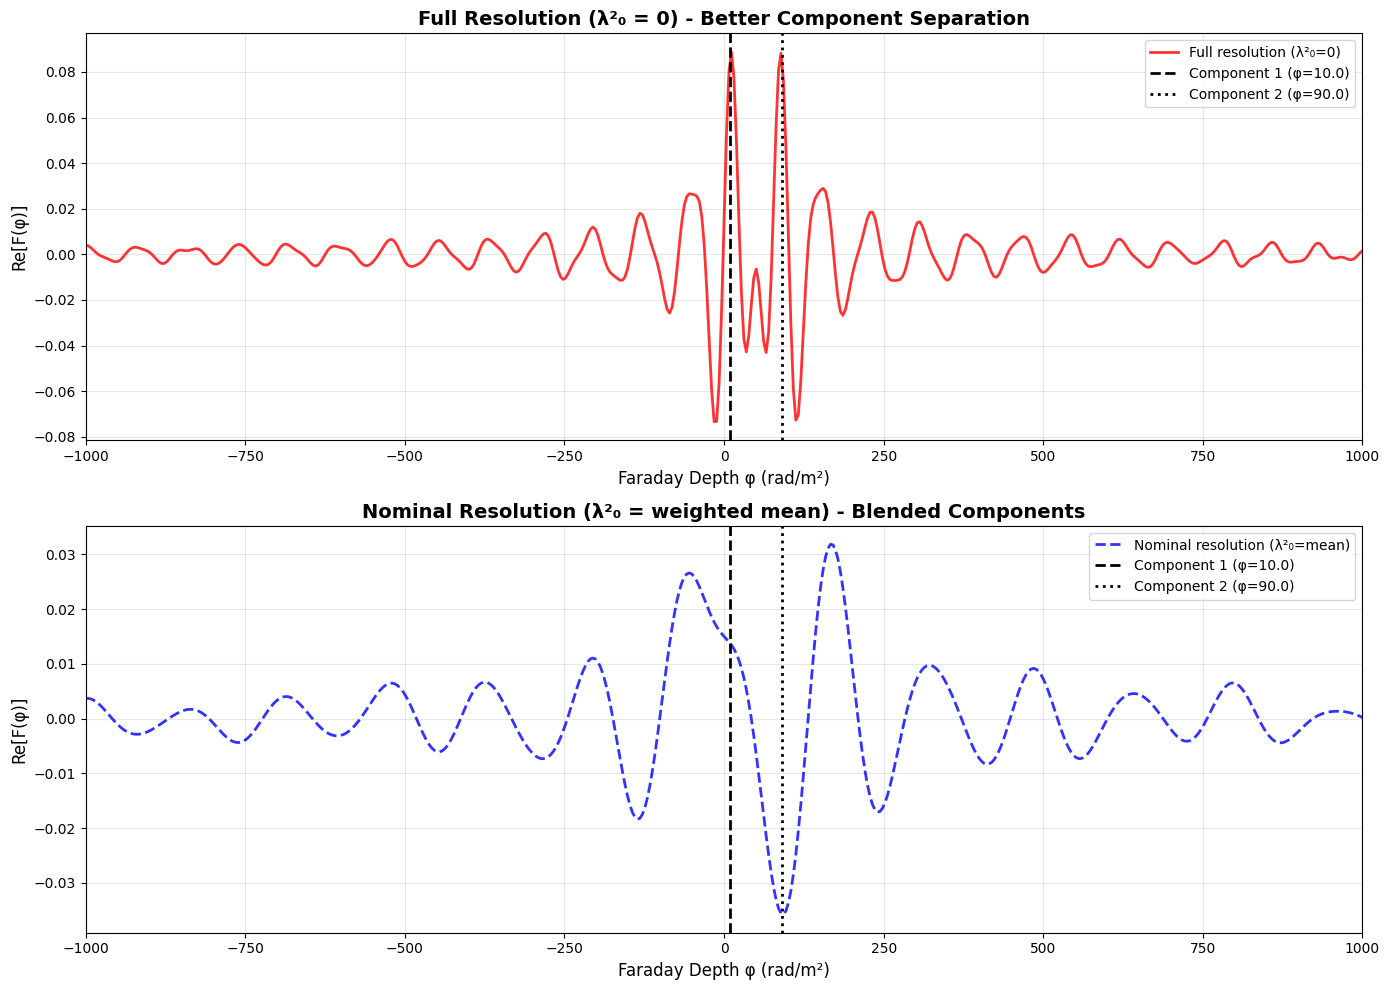


Key Observation:
Full resolution provides better separation of closely spaced components.
This is the main advantage identified by Rudnick & Cotton (2023).


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full resolution: Re[F(φ)] shows the two components as distinct peaks
ax = axes[0]
ax.plot(phi, fd_dirty_full_np.real, 'r-', linewidth=2, label='Full resolution (λ²₀=0)', alpha=0.8)
ax.axvline(
    source1.phi_gal,
    color='k',
    linestyle='--',
    linewidth=2,
    label=f'Component 1 (φ={source1.phi_gal:.1f})'
)
ax.axvline(
    source2.phi_gal,
    color='k',
    linestyle=':',
    linewidth=2,
    label=f'Component 2 (φ={source2.phi_gal:.1f})'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('Re[F(φ)]', fontsize=12)
ax.set_title(
    'Full Resolution (λ²₀ = 0) - Better Component Separation', fontsize=14, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Nominal resolution: Re[F(φ)] blends the two components together
ax = axes[1]
ax.plot(
    phi, fd_dirty_nom_np.real, 'b--', linewidth=2, label='Nominal resolution (λ²₀=mean)', alpha=0.8
)
ax.axvline(
    source1.phi_gal,
    color='k',
    linestyle='--',
    linewidth=2,
    label=f'Component 1 (φ={source1.phi_gal:.1f})'
)
ax.axvline(
    source2.phi_gal,
    color='k',
    linestyle=':',
    linewidth=2,
    label=f'Component 2 (φ={source2.phi_gal:.1f})'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('Re[F(φ)]', fontsize=12)
ax.set_title(
    'Nominal Resolution (λ²₀ = weighted mean) - Blended Components', fontsize=14, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("Full resolution provides better separation of closely spaced components.")
print("This is the main advantage identified by Rudnick & Cotton (2023).")

## 4. Reconstruction with Full Resolution

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
[restore DEBUG]
  cellsize=3.878084  rmtf_fwhm=15.405926  pixels_per_rmtf=3.9726
  peak:  dirty=9.120820e-02  model=5.797082e-03  residual=3.868863e-05
  peak:  conv_model(Jy/rmtf)=1.649657e-02 restored=1.649576e-02
  sum|model|=5.060191e-01  sum|conv_model|=1.525631e+00
  peak:  conv_abs_model=2.398190e-02 (amp-restored)
  ratio dirty_peak/model_pe

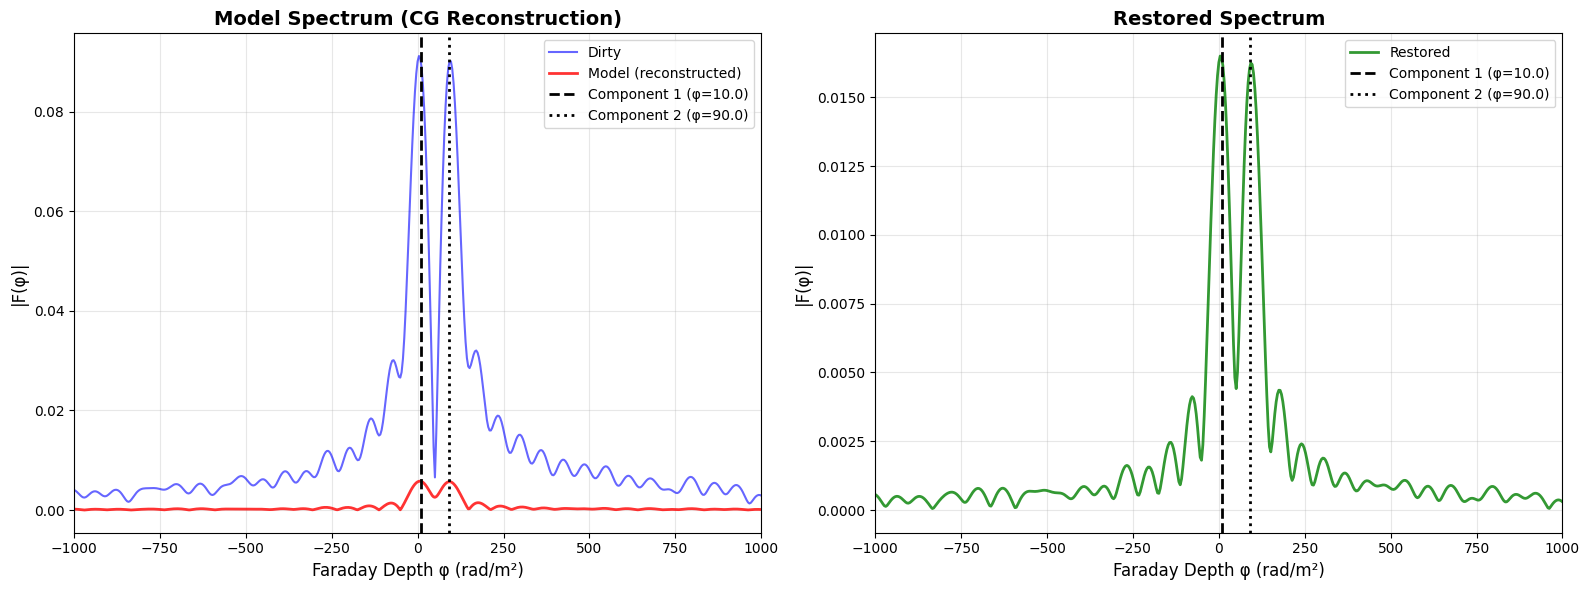


Reconstruction Summary:
  Component 1 true: φ = 10.0 rad/m²
  Component 2 true: φ = 90.0 rad/m²
  Model RM: 7.8 rad/m²

Note: For multiple components, the model RM represents a weighted average.
Individual components can be identified from the restored spectrum.


In [5]:
# Use full resolution for reconstruction
source_multi.l2_ref = 0.0

recon = CSROMERReconstructorWrapper(
    dataset=source_multi,
    oversampling=4.0,
    optimizer_factory=make_cg_optimizer(maxiter=100, tol=1e-12, verbose=False),
)
recon.reconstruct()

fd_model = np.asarray(asnumpy(recon.fd_model))
fd_restored = np.asarray(asnumpy(recon.fd_restored))
# Reconstructor uses full resolution (l2_ref=0); use its phi for consistent axes
phi_recon = np.asarray(asnumpy(recon.parameter.phi))

# Plot reconstruction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model spectrum (all on recon grid: full resolution)
ax = axes[0]
ax.plot(phi_recon, np.abs(fd_dirty_full_np), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi_recon, np.abs(fd_model), 'r-', linewidth=2, label='Model (reconstructed)', alpha=0.8)
ax.axvline(
    source1.phi_gal,
    color='k',
    linestyle='--',
    linewidth=2,
    label=f'Component 1 (φ={source1.phi_gal:.1f})'
)
ax.axvline(
    source2.phi_gal,
    color='k',
    linestyle=':',
    linewidth=2,
    label=f'Component 2 (φ={source2.phi_gal:.1f})'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (CG Reconstruction)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Restored spectrum
ax = axes[1]
ax.plot(phi_recon, np.abs(fd_restored), 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(
    source1.phi_gal,
    color='k',
    linestyle='--',
    linewidth=2,
    label=f'Component 1 (φ={source1.phi_gal:.1f})'
)
ax.axvline(
    source2.phi_gal,
    color='k',
    linestyle=':',
    linewidth=2,
    label=f'Component 2 (φ={source2.phi_gal:.1f})'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

print("\nReconstruction Summary:")
print(f"  Component 1 true: φ = {source1.phi_gal:.1f} rad/m²")
print(f"  Component 2 true: φ = {source2.phi_gal:.1f} rad/m²")
print(f"  Model RM: {recon.rm_model:.1f} rad/m²")
print(f"\nNote: For multiple components, the model RM represents a weighted average.")
print(f"Individual components can be identified from the restored spectrum.")